In [2]:
import os
os.chdir("./..")

from PVDataset import PVDataset

ds = PVDataset(r"C:\Users\peter\Repos\ENFIELD-data\processed_unpack\nwp_0h", "Slovakia", "top", "train")

In [3]:
from models.ADRInspired import ADRInspired as ADR
from utils.config import load_config
import torch

config = load_config("./config/ADR.yaml")
model_fit = ADR(config)
model_fit.load_state_dict(torch.load(r"C:\Users\peter\Repos\ENFIELD-PIML\checkpoints\PV-PIML\fit_Slovakia\epoch=36-step=148.ckpt", weights_only=False)["state_dict"])

model_default = ADR(config)

W0429 23:09:17.195000 26312 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [57]:
for name, param in model_default.named_parameters():
    print(f"{name}: {param.detach().cpu().numpy():.3f}")

albedo: 0.463
u0: 24.194
u1: 7.491
k_a: 2.549
k_d: -7.697
tc_d: 0.057
k_rs: -0.059
k_rsh: -0.006


In [35]:
for name, param in model_fit.named_parameters():
    print(f"{name}: {param.detach().cpu().numpy():.3f}")

albedo: 0.566
u0: 26.539
u1: 7.085
k_a: 0.851
k_d: -7.493
tc_d: 0.104
k_rs: 0.380
k_rsh: 1.301


In [58]:
for name, param in model_fit.named_parameters():
    print(f"{name}: {param.detach().cpu().numpy():.3f}")

albedo: 0.554
u0: 26.279
u1: 6.367
k_a: 0.851
k_d: -7.159
tc_d: 0.092
k_rs: 0.382
k_rsh: 1.260


In [60]:
for name, param in model_fit.named_parameters():
    print(f"{name}: {param.detach().cpu().numpy():.3f}")

albedo: 0.437
u0: 26.249
u1: 7.524
k_a: 0.888
k_d: -7.515
tc_d: 0.103
k_rs: 0.354
k_rsh: 1.230


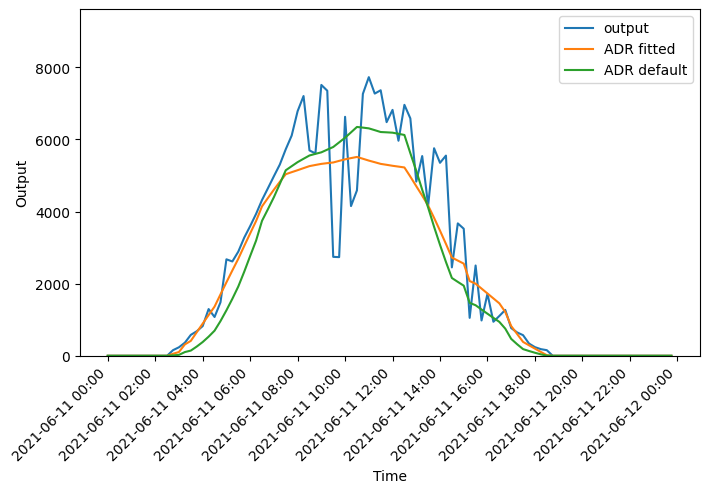

In [12]:
import torch
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

import random

x, y, metadata = ds[random.randint(0, len(ds)-1)]
metadata_tensors = {}
for k, v in metadata.items():
    try:
        metadata_tensors[k] = torch.tensor(v).unsqueeze(0)
    except (TypeError, ValueError):
        metadata_tensors[k] = [v]

y_hat = model_fit([t.unsqueeze(0) for t in x], metadata_tensors)
fitted_prediction = y_hat.detach().numpy()

y_hat = model_default([t.unsqueeze(0) for t in x], metadata_tensors)
default_prediction = y_hat.detach().numpy()

fig, ax = plt.subplots(1, 1, figsize=(8, 4.5))
ax.plot(pd.to_datetime(x[-1], unit="s"), y*4000, label="output")
ax.plot(pd.to_datetime(x[-1], unit="s"), fitted_prediction[0], label="ADR fitted")
ax.plot(pd.to_datetime(x[-1], unit="s"), default_prediction[0], label="ADR default")
ax.set_xlabel("Time")
ax.set_ylabel("Output")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.xticks(rotation=45, ha='right')
ax.set_ylim(0,9610)
plt.show()